In [1]:
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import cifar10
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model


In [7]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Loaded MNIST ")

Loaded MNIST 


In [9]:
import tensorflow as tf
import pathlib
import tarfile
import urllib.request

# alternative mirror (GitHub)
url = "https://github.com/YoongiKim/CIFAR-10-images/archive/refs/heads/master.zip"

path = pathlib.Path("cifar10.zip")

if not path.exists():
    urllib.request.urlretrieve(url, path)

print("Downloaded from alternative source ")

Downloaded from alternative source 


In [11]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.1, random_state=0
)

In [13]:
print('Train Images Shape:      ', X_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nValidation Images Shape: ', X_valid.shape)
print('Validation Labels Shape: ', y_valid.shape)

print('\nTest Images Shape:       ', X_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (54000, 28, 28)
Train Labels Shape:       (54000,)

Validation Images Shape:  (6000, 28, 28)
Validation Labels Shape:  (6000,)

Test Images Shape:        (10000, 28, 28)
Test Labels Shape:        (10000,)


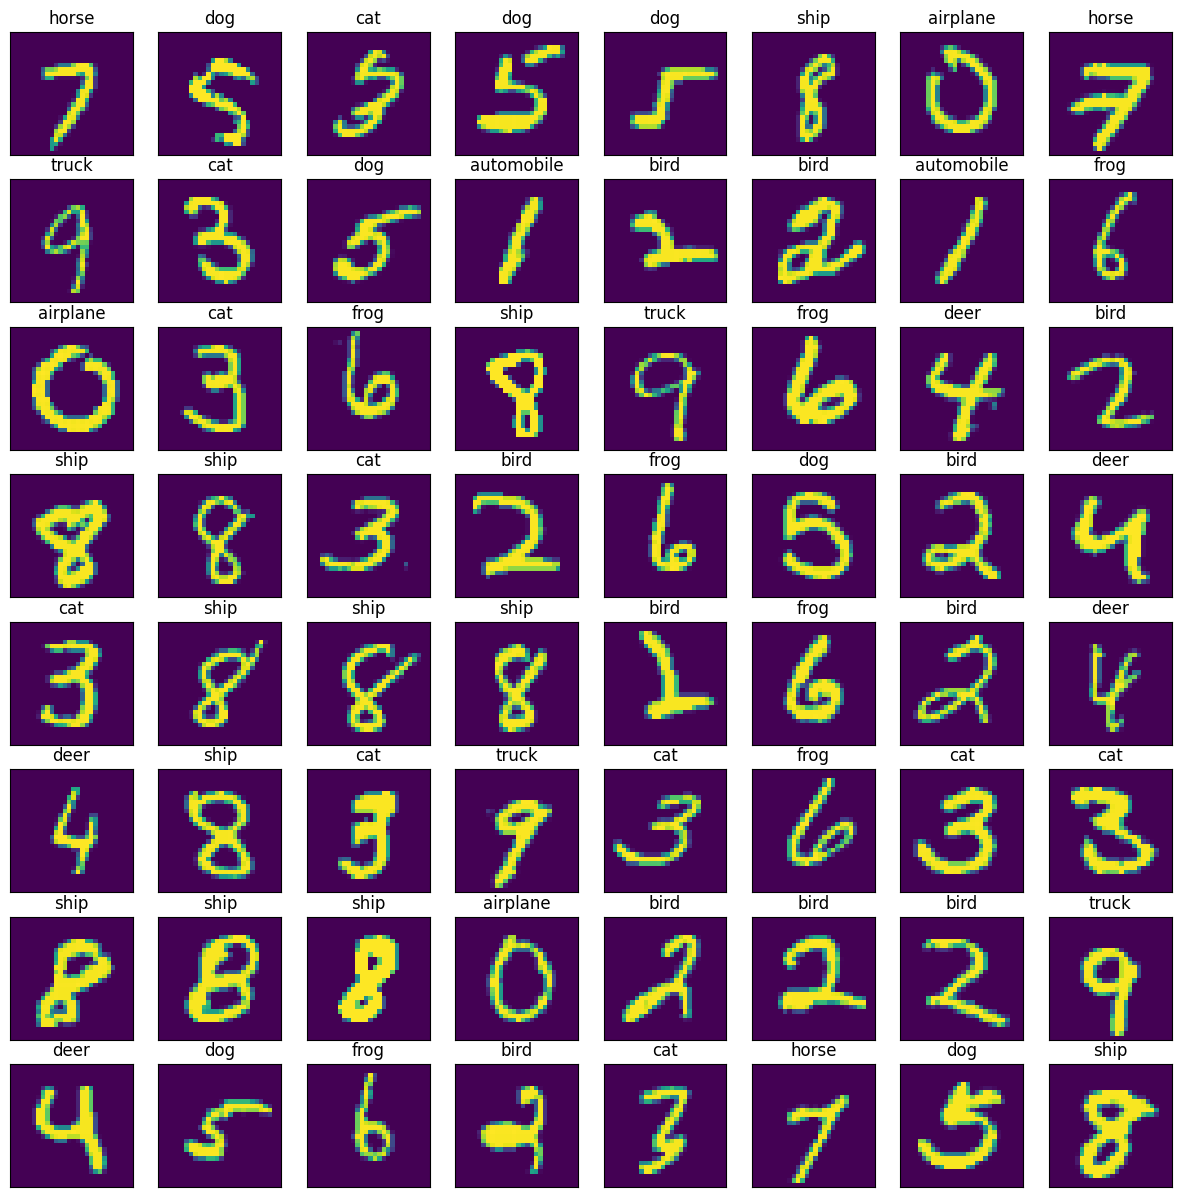

In [15]:
# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

import matplotlib.pyplot as plt

# Create a new figure
plt.figure(figsize=(15, 15))

# Loop over the first 64 images
for i in range(64):
    plt.subplot(8, 8, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display image
    plt.imshow(X_train[i])

    # FIX: remove [0]
    plt.title(class_names[y_train[i]], fontsize=12)

# Show plot
plt.show()

In [16]:
# Convert pixel values data type to float32
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')
X_valid = X_valid.astype('float32')

# Calculate the mean and standard deviation of the training images
mean = np.mean(X_train)
std  = np.std(X_train)

# Normalize the data
# The tiny value 1e-7 is added to prevent division by zero
X_train = (X_train-mean)/(std+1e-7)
X_test  = (X_test-mean) /(std+1e-7)
X_valid = (X_valid-mean)/(std+1e-7)

In [17]:
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)
y_test  = to_categorical(y_test, 10)


In [18]:
# Data augmentation
data_generator = ImageDataGenerator(
    # Rotate images randomly by up to 15 degrees
    rotation_range=15,
    
    # Shift images horizontally by up to 12% of their width
    width_shift_range=0.12,
    
    # Shift images vertically by up to 12% of their height
    height_shift_range=0.12,
    
    # Randomly flip images horizontally
    horizontal_flip=True,
    
    # Zoom images in by up to 10%
    zoom_range=0.1,
    
    # Change brightness by up to 10%
    brightness_range=[0.9,1.1],

    # Shear intensity (shear angle in counter-clockwise direction in degrees)
    shear_range=10,
    
    # Channel shift intensity
    channel_shift_range=0.1,
)

In [21]:

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.regularizers import l2

(X_train, y_train), (X_test, y_test) = mnist.load_data()


X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# Normalize
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print("Shape:", X_train.shape)   # (60000, 28, 28, 1)


model = Sequential()
weight_decay = 0.0001

# Block 1
model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                 kernel_regularizer=l2(weight_decay),
                 input_shape=(28,28,1)))
model.add(BatchNormalization())

model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Block 2
model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# Block 3 (last block for MNIST)
model.add(Conv2D(128, (3,3), padding='same', activation='relu',
                 kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.4))

# Output
model.add(Flatten())
model.add(Dense(10, activation='softmax'))


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)


test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

Shape: (60000, 28, 28, 1)


Epoch 1/10


844/844 [==============================] - 96s 111ms/step - loss: 0.2721 - accuracy: 0.9292 - val_loss: 0.0768 - val_accuracy: 0.9877
Epoch 2/10
844/844 [==============================] - 107s 127ms/step - loss: 0.0997 - accuracy: 0.9780 - val_loss: 0.0615 - val_accuracy: 0.9903
Epoch 3/10
844/844 [==============================] - 227s 269ms/step - loss: 0.0832 - accuracy: 0.9834 - val_loss: 0.0626 - val_accuracy: 0.9912
Epoch 4/10
844/844 [==============================] - 187s 222ms/step - loss: 0.0801 - accuracy: 0.9851 - val_loss: 0.0772 - val_accuracy: 0.9890
Epoch 5/10
844/844 [==============================] - 194s 230ms/step - loss: 0.0773 - accuracy: 0.9860 - val_loss: 0.0606 - val_accuracy: 0.9930
Epoch 6/10
844/844 [==============================] - 176s 209ms/step - loss: 0.0725 - accuracy: 0.9883 - val_loss: 0.0684 - val_accuracy: 0.9925
Epoch 7/10
844/844 [==============================] - 198s 235ms/step - loss: 0.0746 - accuracy

In [22]:
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 batch_normalization_1 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                      

In [9]:
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.1,   
    callbacks=[reduce_lr, early_stopping],
    verbose=2
)

Epoch 1/10
844/844 - 26s - loss: 0.0803 - accuracy: 0.9768 - val_loss: 0.0725 - val_accuracy: 0.9812 - lr: 5.0000e-04 - 26s/epoch - 30ms/step
Epoch 2/10
844/844 - 21s - loss: 0.0679 - accuracy: 0.9808 - val_loss: 0.0642 - val_accuracy: 0.9832 - lr: 5.0000e-04 - 21s/epoch - 25ms/step
Epoch 3/10
844/844 - 18s - loss: 0.0596 - accuracy: 0.9829 - val_loss: 0.0659 - val_accuracy: 0.9828 - lr: 5.0000e-04 - 18s/epoch - 22ms/step
Epoch 4/10
844/844 - 19s - loss: 0.0535 - accuracy: 0.9843 - val_loss: 0.0589 - val_accuracy: 0.9842 - lr: 5.0000e-04 - 19s/epoch - 22ms/step
Epoch 5/10
844/844 - 23s - loss: 0.0490 - accuracy: 0.9857 - val_loss: 0.0553 - val_accuracy: 0.9852 - lr: 5.0000e-04 - 23s/epoch - 27ms/step
Epoch 6/10
844/844 - 16s - loss: 0.0443 - accuracy: 0.9873 - val_loss: 0.0577 - val_accuracy: 0.9840 - lr: 5.0000e-04 - 16s/epoch - 19ms/step
Epoch 7/10
844/844 - 18s - loss: 0.0410 - accuracy: 0.9883 - val_loss: 0.0562 - val_accuracy: 0.9858 - lr: 5.0000e-04 - 18s/epoch - 22ms/step
Epoch 

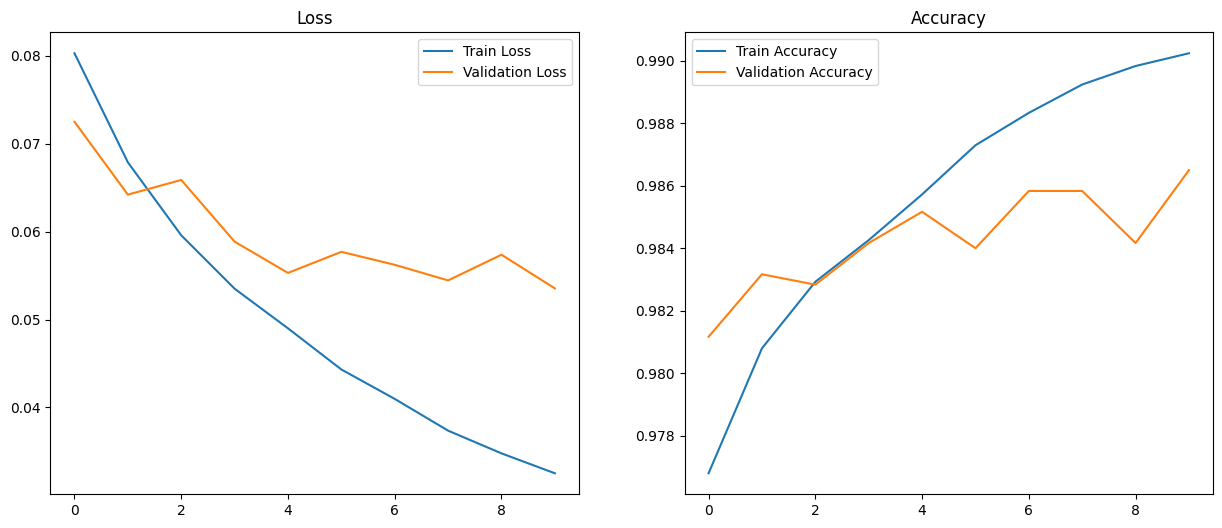

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()